<a href="https://colab.research.google.com/github/yashdevale25/Data-Science-Lab/blob/main/DSLab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Experiment 05 : Data Manipulation using Open-Source Dataset in Python

Importing Dataset from Kaggle

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alehcleal/ferrari-stock-data-2015-2026")

print("Path to dataset files:", path)

100%|██████████| 97.3k/97.3k [00:00<00:00, 26.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/alehcleal/ferrari-stock-data-2015-2026/versions/1


Importing Libraries

In [ ]:
import numpy as np
import pandas as pd

 Data Manipulation Using Python (Pandas)
Import Dataset

In [ ]:
import os
os.listdir("/content/drive/MyDrive/DS lab/Lab5/archive")

['Ferrari History Stock Data.csv']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

path = "/content/drive/MyDrive/DS lab/Lab5/archive/Ferrari History Stock Data.csv"

df = pd.read_csv(path)

print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
         Date      Close       High        Low       Open    Volume
0  2015-10-21  50.845524  56.364575  50.845524  55.467844  22498800
1  2015-10-22  52.463337  53.803811  51.492650  52.759165   4545100
2  2015-10-23  52.121284  53.618915  52.019593  53.406289   1967600
3  2015-10-26  50.864014  52.694452  50.420271  52.694452   1466300
4  2015-10-27  49.782391  50.836283  45.631549  50.660632   5949200


Dataset Information

In [ ]:
print("\nDataset Information:")
print(df.info())

print("\nDataset Description:")
print(df.describe())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2598 entries, 0 to 2597
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2598 non-null   object 
 1   Close   2598 non-null   float64
 2   High    2598 non-null   float64
 3   Low     2598 non-null   float64
 4   Open    2598 non-null   float64
 5   Volume  2598 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 121.9+ KB
None

Dataset Description:
             Close         High          Low         Open        Volume
count  2598.000000  2598.000000  2598.000000  2598.000000  2.598000e+03
mean    212.158698   213.889960   210.419942   212.154888  4.709579e+05
std     132.058569   132.996605   131.097749   132.057662  6.197347e+05
min      29.582851    30.026594    29.268533    29.850947  5.380000e+04
25%     113.411070   114.653173   112.025279   113.923913  2.474000e+05
50%     185.648178   188.069001   183.788222   185.73

Data Filtering

In [ ]:
#Example 1: Closing price greater than 200
high_close = df[df['Close'] > 200]

print("\nDays when closing price > 200:")
print(high_close.head())


Days when closing price > 200:
            Date       Close        High         Low        Open  Volume
1270  2020-11-05  200.345734  200.510196  196.824277  197.530500  379400
1271  2020-11-06  201.226105  202.135494  199.774955  200.258672  481600
1274  2020-11-11  202.454758  203.219023  201.051982  201.051982  195900
1277  2020-11-16  200.906845  202.116137  199.001001  201.709816  274100
1278  2020-11-17  203.499573  205.105501  202.783667  203.847849  302400


Create Year Column for Grouping

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

print("\nDataset with Year column:")
print(df.head())


Dataset with Year column:
        Date      Close       High        Low       Open    Volume  Year
0 2015-10-21  50.845524  56.364575  50.845524  55.467844  22498800  2015
1 2015-10-22  52.463337  53.803811  51.492650  52.759165   4545100  2015
2 2015-10-23  52.121284  53.618915  52.019593  53.406289   1967600  2015
3 2015-10-26  50.864014  52.694452  50.420271  52.694452   1466300  2015
4 2015-10-27  49.782391  50.836283  45.631549  50.660632   5949200  2015


Grouping Data by Year

In [ ]:
grouped_data = df.groupby('Year')

print("\nGrouped Data:")
print(grouped_data.head())


Grouped Data:
           Date       Close        High         Low        Open    Volume  \
0    2015-10-21   50.845524   56.364575   50.845524   55.467844  22498800   
1    2015-10-22   52.463337   53.803811   51.492650   52.759165   4545100   
2    2015-10-23   52.121284   53.618915   52.019593   53.406289   1967600   
3    2015-10-26   50.864014   52.694452   50.420271   52.694452   1466300   
4    2015-10-27   49.782391   50.836283   45.631549   50.660632   5949200   
50   2016-01-04   43.810349   44.198625   42.904374   43.717904   2507000   
51   2016-01-05   44.827259   45.049128   43.865816   44.928947   1934400   
52   2016-01-06   43.514526   44.244854   43.061541   44.143162   2554900   
53   2016-01-07   43.126255   43.523775   42.673266   42.913625   1775300   
54   2016-01-08   39.853642   43.107755   39.853642   43.080019   5116900   
302  2017-01-03   55.181889   55.481485   54.629508   55.387862    546700   
303  2017-01-04   55.621918   55.687454   55.041451   55.0882

Aggregate Statistics

Mean Closing Price per Year

In [ ]:
print("\nMean Closing Price per Year:")
print(df.groupby('Year')['Close'].mean())


Mean Closing Price per Year:
Year
2015     45.839737
2016     42.898842
2017     86.078304
2018    118.000906
2019    141.055395
2020    172.158963
2021    212.414650
2022    202.048305
2023    293.167859
2024    422.060983
2025    447.195497
2026    354.909412
Name: Close, dtype: float64


Total Volume per Year

In [ ]:
print("\nTotal Volume per Year:")
print(df.groupby('Year')['Volume'].sum())


Total Volume per Year:
Year
2015     70244200
2016    173509400
2017    143317200
2018    157306800
2019     99901700
2020     86284800
2021     81671600
2022     97582000
2023     84993200
2024     70230100
2025    129147700
2026     29360000
Name: Volume, dtype: int64


Count of Records per Year

In [ ]:
print("\nNumber of records per Year:")
print(df.groupby('Year')['Close'].count())


Number of records per Year:
Year
2015     50
2016    252
2017    251
2018    251
2019    252
2020    253
2021    252
2022    251
2023    250
2024    252
2025    250
2026     34
Name: Close, dtype: int64


Minimum Price per Year

In [ ]:
print("\nMinimum Low Price per Year:")
print(df.groupby('Year')['Low'].min())


Minimum Low Price per Year:
Year
2015     41.277321
2016     29.268533
2017     53.889883
2018     89.354204
2019     91.991512
2020    122.628959
2021    177.833576
2022    163.886370
2023    209.416330
2024    325.457020
2025    356.929993
2026    328.000000
Name: Low, dtype: float64


Maximum Price per Year

In [ ]:
print("\nMaximum High Price per Year:")
print(df.groupby('Year')['High'].max())


Maximum High Price per Year:
Year
2015     56.364575
2016     55.106995
2017    114.517120
2018    142.671562
2019    165.985443
2020    226.050447
2021    271.029347
2022    264.389239
2023    367.120621
2024    494.290104
2025    519.099976
2026    393.500000
Name: High, dtype: float64


#Data Visualization


Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/DS lab/Lab5/archive/Ferrari History Stock Data.csv"

df = pd.read_csv(path)

df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Line Chart (Stock Price Trend)

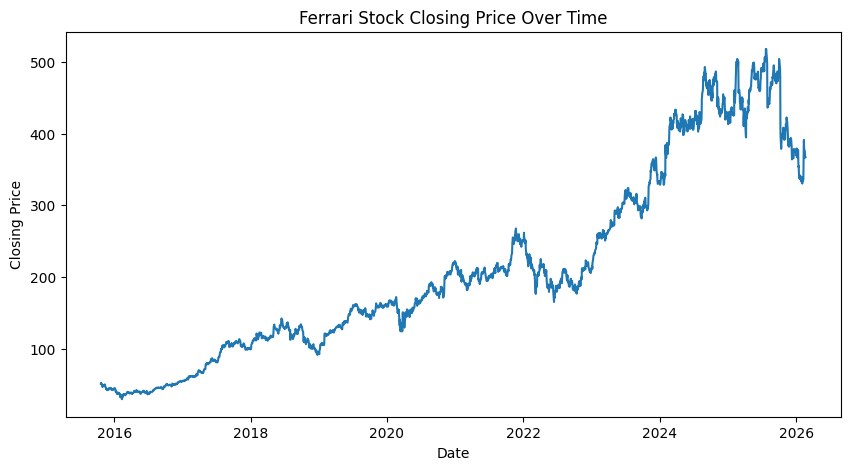

In [4]:
plt.figure(figsize=(10,5))

plt.plot(df['Date'], df['Close'])

plt.title("Ferrari Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

Scatter Plot (Volume vs Close Price)

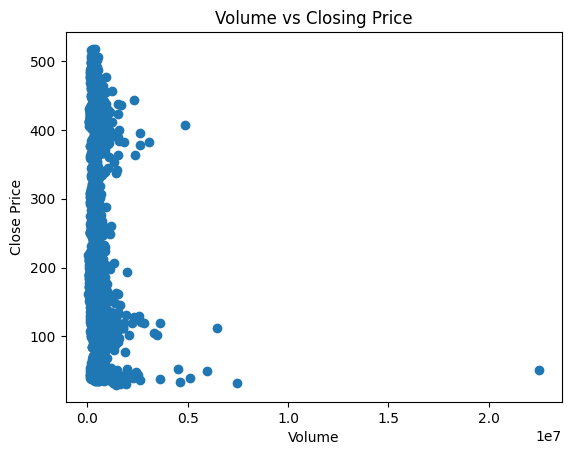

In [5]:
plt.scatter(df['Volume'], df['Close'])

plt.title("Volume vs Closing Price")
plt.xlabel("Volume")
plt.ylabel("Close Price")

plt.show()